In [1]:
import $ivy.`org.apache.spark::spark-core:3.5.0`
import $ivy.`org.apache.spark::spark-sql:3.5.0`

import org.apache.spark.sql.SparkSession
import org.apache.spark.HashPartitioner
import org.apache.spark.RangePartitioner

val spark = SparkSession.builder()
  .appName("Dia13S2_PairRDDs")
  .master("local[*]")
  .config("spark.ui.showConsoleProgress", "false")
  .getOrCreate()

val sc = spark.sparkContext
sc.setLogLevel("ERROR")

println(s"✅ Spark ${spark.version} listo")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/24 10:52:53 INFO SparkContext: Running Spark version 3.5.0
26/04/24 10:52:53 INFO SparkContext: OS info Windows 11, 10.0, amd64
26/04/24 10:52:53 INFO SparkContext: Java version 17.0.18
26/04/24 10:52:54 WARN Shell: Did not find winutils.exe: java.io.FileNotFoundException: java.io.FileNotFoundException: HADOOP_HOME and hadoop.home.dir are unset. -see https://wiki.apache.org/hadoop/WindowsProblems
26/04/24 10:52:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/24 10:52:54 INFO ResourceUtils: ==============================================================
26/04/24 10:52:54 INFO ResourceUtils: No custom resources configured for spark.driver.
26/04/24 10:52:54 INFO ResourceUtils: ==============================================================
26/04/24 10:52:54 INFO SparkContext: Submitted application: Dia13S2_PairRDDs
26/0

✅ Spark 3.5.0 listo


import $ivy.$
import $ivy.$
import org.apache.spark.sql.SparkSession
import org.apache.spark.HashPartitioner
import org.apache.spark.RangePartitioner
spark: SparkSession = org.apache.spark.sql.SparkSession@500d6207
sc: org.apache.spark.SparkContext = org.apache.spark.SparkContext@318c2c7f

 Ejercicio 1 — Análisis de ventas por región

Trabajarás con un dataset simulado de ventas de una empresa distribuidora 

con tres regiones: Norte, Centro y Sur.
Datos:

In [2]:
// Dataset de ventas: (producto, región, importe, unidades)
val datosVentas = sc.parallelize(List(
  ("Laptop",    "Norte",  1200.0, 3),
  ("Teclado",   "Sur",      45.0, 10),
  ("Monitor",   "Norte",   350.0, 5),
  ("Laptop",    "Sur",    1200.0, 2),
  ("Ratón",     "Norte",    25.0, 20),
  ("Monitor",   "Centro",  350.0, 4),
  ("Teclado",   "Norte",    45.0, 8),
  ("Laptop",    "Centro", 1200.0, 1),
  ("Auriculares","Sur",     80.0, 6),
  ("Ratón",     "Centro",   25.0, 15),
  ("Auriculares","Norte",   80.0, 9),
  ("Teclado",   "Centro",   45.0, 12)
))

println(s"Total registros: ${datosVentas.count()}")

Total registros: 12


datosVentas: org.apache.spark.rdd.RDD[(String, String, Double, Int)] = ParallelCollectionRDD[0] at parallelize at cmd2.sc:2

In [5]:
// Paso 1: crear Pair RDD (región, importe_total_línea)
// El importe de cada línea es: importe_unitario * unidades
val importesPorRegion = datosVentas.map { case (producto, region, precio, uds) =>
  (region, precio * uds)
}

// Paso 2: sumar importes por región
val totalPorRegion = importesPorRegion.reduceByKey(_ + _)

println("=== Total de ventas por región ===")
totalPorRegion.sortBy(_._2, ascending = false).collect().foreach {
  case (region, total) => println(f"  $region%-10s → $total%,.2f €")
}

=== Total de ventas por región ===
  Norte      → 6.930,00 €
  Centro     → 3.515,00 €
  Sur        → 3.330,00 €


importesPorRegion: org.apache.spark.rdd.RDD[(String, Double)] = MapPartitionsRDD[8] at map at cmd5.sc:3
totalPorRegion: org.apache.spark.rdd.RDD[(String, Double)] = ShuffledRDD[9] at reduceByKey at cmd5.sc:8

Paso 2: media de importe por región

In [6]:
// Usamos aggregateByKey para calcular (suma, count) y luego la media
val mediasPorRegion = importesPorRegion.aggregateByKey(
  (0.0, 0)
)(
  (acc, v) => (acc._1 + v, acc._2 + 1),
  (a, b)   => (a._1 + b._1, a._2 + b._2)
)

println("=== Media de importe por venta y región ===")
mediasPorRegion.collect().foreach { case (region, (suma, count)) =>
  val media = suma / count
  println(f"  $region%-10s → media $media%,.2f € (sobre $count transacciones)")
}

=== Media de importe por venta y región ===
  Sur        → media 1.110,00 € (sobre 3 transacciones)
  Norte      → media 1.386,00 € (sobre 5 transacciones)
  Centro     → media 878,75 € (sobre 4 transacciones)


mediasPorRegion: org.apache.spark.rdd.RDD[(String, (Double, Int))] = ShuffledRDD[15] at aggregateByKey at cmd6.sc:4

Paso 3: lista de productos por región

In [7]:
// Usamos combineByKey para obtener la lista de productos por región
val productosPorRegion = datosVentas.map { case (producto, region, _, _) =>
  (region, producto)
}.combineByKey(
  (v: String) => List(v),
  (acc: List[String], v: String) => (acc :+ v).distinct,
  (acc1: List[String], acc2: List[String]) => (acc1 ++ acc2).distinct
)

println("=== Catálogo de productos por región ===")
productosPorRegion.collect().foreach { case (region, productos) =>
  println(s"  $region → ${productos.sorted.mkString(", ")}")
}

=== Catálogo de productos por región ===
  Sur → Auriculares, Laptop, Teclado
  Norte → Auriculares, Laptop, Monitor, Ratón, Teclado
  Centro → Laptop, Monitor, Ratón, Teclado


productosPorRegion: org.apache.spark.rdd.RDD[(String, List[String])] = ShuffledRDD[17] at combineByKey at cmd7.sc:7

 Ejercicio 2 — Medias por categoría con combineByKey

Tienes un log de puntuaciones de estudiantes en distintos módulos. Calcula la nota media,

 la nota máxima y el número de evaluaciones por módulo.

Datos:

In [8]:
// (módulo, nota)
val notasEstudiantes = sc.parallelize(List(
  ("Scala",  8.5), ("Spark",  7.0), ("Scala",  9.0),
  ("BigData",6.5), ("Spark",  8.5), ("Scala",  7.5),
  ("BigData",9.0), ("Spark",  6.0), ("Scala",  8.0),
  ("BigData",7.5), ("Spark",  9.5), ("BigData",8.0),
  ("Scala",  9.5), ("Spark",  7.5), ("BigData",5.5)
))

println(s"Total evaluaciones: ${notasEstudiantes.count()}")

Total evaluaciones: 15


notasEstudiantes: org.apache.spark.rdd.RDD[(String, Double)] = ParallelCollectionRDD[18] at parallelize at cmd8.sc:2

In [9]:
// Acumulador: (suma, máximo, count)
// Tipo de combinación: (Double, Double, Int)

val estadisticasPorModulo = notasEstudiantes.combineByKey(
  // createCombiner: primer valor → (suma, max, count=1)
  (nota: Double) => (nota, nota, 1),

  // mergeValue: actualizar acumulador con un nuevo valor
  (acc: (Double, Double, Int), nota: Double) =>
    (acc._1 + nota, scala.math.max(acc._2, nota), acc._3 + 1),

  // mergeCombiners: unir dos acumuladores de distintas particiones
  (a: (Double, Double, Int), b: (Double, Double, Int)) =>
    (a._1 + b._1, scala.math.max(a._2, b._2), a._3 + b._3)
)

println("=== Estadísticas por módulo ===")
println(f"${"Módulo"}%-12s ${"Media"}%8s ${"Máximo"}%8s ${"Evaluc."}%8s")
println("-" * 42)

estadisticasPorModulo.collect().sortBy(_._1).foreach {
  case (modulo, (suma, maximo, count)) =>
    val media = suma / count
    println(f"$modulo%-12s $media%8.2f $maximo%8.1f $count%8d")
}

=== Estadísticas por módulo ===
Módulo          Media   Máximo  Evaluc.
------------------------------------------
BigData          7,30      9,0        5
Scala            8,50      9,5        5
Spark            7,70      9,5        5


estadisticasPorModulo: org.apache.spark.rdd.RDD[(String, (Double, Double, Int))] = ShuffledRDD[19] at combineByKey at cmd9.sc:13

🔹 Ejercicio 3 — Contar clics por usuario en un log simulado
Tienes un log de eventos de una plataforma web. Cada línea registra: usuario, sección visitada y duración en segundos. Extrae métricas por usuario.

Datos del log

In [10]:
// Log de eventos: "usuario,sección,segundos"
val logEventos = sc.parallelize(List(
  "u001,inicio,12",    "u002,cursos,45",   "u001,cursos,120",
  "u003,inicio,8",     "u001,video,300",   "u002,video,250",
  "u003,cursos,90",    "u004,inicio,5",    "u002,inicio,15",
  "u001,foro,60",      "u003,video,180",   "u004,cursos,75",
  "u002,foro,40",      "u003,foro,30",     "u004,video,200",
  "u001,cursos,95",    "u004,foro,55",     "u003,inicio,10",
  "u002,cursos,110",   "u001,inicio,20"
))

println(s"Total eventos en el log: ${logEventos.count()}")

Total eventos en el log: 20


logEventos: org.apache.spark.rdd.RDD[String] = ParallelCollectionRDD[20] at parallelize at cmd10.sc:2

In [11]:
// Paso 1: convertir a Pair RDD (usuario, segundos)
val clicsPorUsuario = logEventos.map { linea =>
  val campos  = linea.split(",")
  val usuario = campos(0)
  val segundos = campos(2).toInt
  (usuario, segundos)
}

// Paso 2: aggregateByKey para (total_segundos, num_clics, max_sesion)
val metricasPorUsuario = clicsPorUsuario.aggregateByKey(
  (0, 0, 0)   // (total_seg, clics, max_seg)
)(
  (acc, seg) => (acc._1 + seg, acc._2 + 1, scala.math.max(acc._3, seg)),
  (a, b)     => (a._1 + b._1, a._2 + b._2, scala.math.max(a._3, b._3))
)

println("=== Métricas de actividad por usuario ===")
println(f"${"Usuario"}%-10s ${"Clics"}%7s ${"Total(s)"}%10s ${"Max(s)"}%8s ${"Media(s)"}%10s")
println("-" * 50)

metricasPorUsuario.collect().sortBy(_._1).foreach {
  case (usuario, (total, clics, maxSeg)) =>
    val media = total.toDouble / clics
    println(f"$usuario%-10s $clics%7d $total%10d $maxSeg%8d $media%10.1f")
}

=== Métricas de actividad por usuario ===
Usuario      Clics   Total(s)   Max(s)   Media(s)
--------------------------------------------------
u001             6        607      300      101,2
u002             5        460      250       92,0
u003             5        318      180       63,6
u004             4        335      200       83,8


clicsPorUsuario: org.apache.spark.rdd.RDD[(String, Int)] = MapPartitionsRDD[21] at map at cmd11.sc:2
metricasPorUsuario: org.apache.spark.rdd.RDD[(String, (Int, Int, Int))] = ShuffledRDD[22] at aggregateByKey at cmd11.sc:12

In [12]:
//Ranking de usuarios por tiempo total:
// Crear Pair RDD (usuario, total_segundos) y ordenar
val rankingUsuarios = metricasPorUsuario.mapValues { case (total, _, _) => total }

println("=== Ranking de usuarios por tiempo en plataforma ===")
rankingUsuarios
  .sortBy(_._2, ascending = false)
  .collect()
  .zipWithIndex
  .foreach { case ((usuario, total), idx) =>
    val minutos = total / 60
    val segs    = total % 60
    println(f"  ${idx + 1}. $usuario%-8s → ${total}s (${minutos}m ${segs}s)")
  }

=== Ranking de usuarios por tiempo en plataforma ===
  1. u001     → 607s (10m 7s)
  2. u002     → 460s (7m 40s)
  3. u004     → 335s (5m 35s)
  4. u003     → 318s (5m 18s)


rankingUsuarios: org.apache.spark.rdd.RDD[(String, Int)] = MapPartitionsRDD[23] at mapValues at cmd12.sc:3

flatMapValues: expandir secciones visitadas:


In [13]:
// Objetivo: obtener todos los pares (usuario, sección) del log
val seccionesPorUsuario = logEventos.map { linea =>
  val campos = linea.split(",")
  (campos(0), campos(1))   // (usuario, sección)
}

// Secciones únicas visitadas por cada usuario
val seccionesUnicas = seccionesPorUsuario
  .groupByKey()
  .mapValues(secciones => secciones.toSet.toList.sorted)

println("=== Secciones visitadas por usuario ===")
seccionesUnicas.collect().sortBy(_._1).foreach { case (usuario, secciones) =>
  println(s"  $usuario → ${secciones.mkString(", ")}")
}

=== Secciones visitadas por usuario ===
  u001 → cursos, foro, inicio, video
  u002 → cursos, foro, inicio, video
  u003 → cursos, foro, inicio, video
  u004 → cursos, foro, inicio, video


seccionesPorUsuario: org.apache.spark.rdd.RDD[(String, String)] = MapPartitionsRDD[29] at map at cmd13.sc:2
seccionesUnicas: org.apache.spark.rdd.RDD[(String, List[String])] = MapPartitionsRDD[31] at mapValues at cmd13.sc:10

 Ejercicio 4 — mapValues vs map con particionado

In [14]:
// Demostración: mapValues preserva el particionador, map no
val rddParticionado = ventasPorRegion
  .partitionBy(new HashPartitioner(4))

println(s"Particionador original: ${rddParticionado.partitioner}")
// Some(org.apache.spark.HashPartitioner@4)

val conMapValues = rddParticionado.mapValues(_ * 1.1)
println(s"Particionador tras mapValues: ${conMapValues.partitioner}")
// Some(org.apache.spark.HashPartitioner@4)   ← ✅ Se preserva

val conMap = rddParticionado.map { case (k, v) => (k, v * 1.1) }
println(s"Particionador tras map: ${conMap.partitioner}")
// None   ← ⚠️ Se pierde el particionado

println("""
  Conclusión:
  - mapValues preserva el particionador → menos shuffles en operaciones posteriores
  - map destruye el particionador → puede causar shuffles innecesarios
""")

cmd14.sc:2: not found: value ventasPorRegion
val rddParticionado = ventasPorRegion
                      ^
Compilation Failed

 Caso de Estudio Propuesto 1: MusicStream Analytics
🎯 Contexto del caso
MusicStream es una plataforma de streaming musical con presencia en cuatro países: España, México, Argentina y Colombia. El equipo de datos ha recopilado un log de reproducciones del último fin de semana y necesita extraer métricas de negocio para el informe semanal.

El archivo de log tiene el siguiente formato por línea:

usuario_id,pais,genero,cancion_id,duracion_segundos,completada
Donde:

usuario_id — identificador del oyente
pais — país desde donde se reproduce
genero — género musical (Pop, Rock, Reggaeton, Jazz, Electronica)
cancion_id — identificador de la canción (formato "artista|titulo")
duracion_segundos — duración de la reproducción en segundos
completada — "S" si escuchó la canción completa, "N" si la saltó
El equipo de negocio ha formulado cinco preguntas concretas que el análisis debe responder. Tu tarea es resolverlas con Pair RDDs usando exclusivamente las herramientas vistas en clase.

In [ ]:
//Datos de caso
// Dataset de reproducciones del fin de semana
val logReproducciones = sc.parallelize(List(
  "u001,España,Pop,Rosalía|Malamente,210,S",
  "u002,México,Reggaeton,BadBunny|Tití,185,S",
  "u001,España,Rock,Vetusta|Cable,240,S",
  "u003,Argentina,Jazz,MilesDavis|So What,320,S",
  "u004,Colombia,Reggaeton,BadBunny|Tití,185,N",
  "u002,México,Pop,Rosalía|Malamente,210,S",
  "u005,España,Electronica,Daft Punk|Harder,224,S",
  "u003,Argentina,Pop,Shakira|Waka,198,N",
  "u006,Colombia,Jazz,ColtraneJ|Giant Steps,280,S",
  "u001,España,Electronica,Daft Punk|Harder,224,N",
  "u007,México,Rock,Mägo|Oro,195,S",
  "u004,Colombia,Pop,Shakira|Waka,198,S",
  "u002,México,Jazz,MilesDavis|So What,320,S",
  "u005,España,Reggaeton,BadBunny|Tití,185,S",
  "u008,Argentina,Rock,Soda|De Música,212,S",
  "u006,Colombia,Electronica,Daft Punk|Harder,224,N",
  "u003,Argentina,Reggaeton,BadBunny|Tití,185,S",
  "u007,México,Pop,Rosalía|Malamente,210,N",
  "u009,España,Jazz,ColtraneJ|Giant Steps,280,S",
  "u008,Argentina,Pop,Rosalía|Malamente,210,S",
  "u010,Colombia,Rock,Mägo|Oro,195,S",
  "u001,España,Reggaeton,J Balvin|Mi Gente,178,S",
  "u009,España,Pop,Shakira|Waka,198,S",
  "u005,España,Rock,Vetusta|Cable,240,S",
  "u010,Colombia,Reggaeton,J Balvin|Mi Gente,178,S",
  "u006,Colombia,Pop,Rosalía|Malamente,210,S",
  "u007,México,Electronica,Daft Punk|Harder,224,S",
  "u002,México,Rock,Soda|De Música,212,S",
  "u008,Argentina,Jazz,MilesDavis|So What,320,N",
  "u004,Colombia,Electronica,Daft Punk|Harder,224,S"
))

logReproducciones: org.apache.spark.rdd.RDD[String] = ParallelCollectionRDD[32] at parallelize at cmd14.sc:3

 Preguntas de negocio
Pregunta 1 — ¿Cuántos minutos totales se han escuchado por país?
El equipo de marketing quiere saber qué países generan más tiempo de escucha total para orientar las campañas publicitarias.

Operaciones necesarias: crear Pair RDD con .map, agregar con reduceByKey, ordenar el resultado.

Pistas:

La clave será el país
El valor será la duración en segundos de cada reproducción
Convierte a minutos al mostrar el resultado (/ 60.0)

In [15]:
// Pregunta 1 — Minutos totales escuchados por país

val segundosPorPais = logReproducciones.map { linea =>
  val campos = linea.split(",")

  val pais = campos(1)
  val duracionSegundos = campos(4).toInt

  (pais, duracionSegundos)
}

val totalSegundosPorPais = segundosPorPais.reduceByKey(_ + _)

println("=== Minutos escuchados por país ===")

totalSegundosPorPais
  .mapValues(segundos => segundos / 60.0)
  .collect()
  .sortBy { case (pais, minutos) => -minutos }
  .foreach { case (pais, minutos) =>
    println(f"$pais%-10s -> $minutos%.1f min")
  }

=== Minutos escuchados por país ===
España     -> 33,0 min
Colombia   -> 28,2 min
México     -> 25,9 min
Argentina  -> 24,1 min


segundosPorPais: org.apache.spark.rdd.RDD[(String, Int)] = MapPartitionsRDD[33] at map at cmd15.sc:3
totalSegundosPorPais: org.apache.spark.rdd.RDD[(String, Int)] = ShuffledRDD[34] at reduceByKey at cmd15.sc:12

Pregunta 2 — ¿Cuál es la tasa de canciones completadas por género?
El equipo de producto necesita saber qué géneros consiguen que los oyentes escuchen las canciones hasta el final. Una tasa baja puede indicar que las canciones de ese género no enganchan.

Operaciones necesarias: map para crear pares (genero, (completadas, total)), aggregateByKey con acumulador (Int, Int).

Pistas:

La clave será el género
El acumulador acumula (num_completadas, num_total)
Al final calcula tasa = completadas.toDouble / total * 100

In [16]:
// Paso 1: (genero, (completada, total))
val reproduccionesPorGenero = logReproducciones.map { linea =>
  val campos = linea.split(",")

  val genero = campos(2)
  val completada = campos(5)

  val completadaInt = if (completada == "S") 1 else 0

  (genero, (completadaInt, 1))
}

// Paso 2: aggregateByKey → (suma_completadas, total)
val tasaPorGenero = reproduccionesPorGenero.aggregateByKey(
  (0, 0)
)(
  (acc, v) => (acc._1 + v._1, acc._2 + v._2),
  (a, b)   => (a._1 + b._1, a._2 + b._2)
)

println("=== Tasa de completado por género ===")

tasaPorGenero
  .collect()
  .sortBy(_._1)
  .foreach { case (genero, (completadas, total)) =>
    val tasa = completadas.toDouble / total * 100
    println(f"$genero%-12s -> $tasa%.1f%% ($completadas/$total reproducciones)")
  }

=== Tasa de completado por género ===
Electronica  -> 60,0% (3/5 reproducciones)
Jazz         -> 80,0% (4/5 reproducciones)
Pop          -> 75,0% (6/8 reproducciones)
Reggaeton    -> 83,3% (5/6 reproducciones)
Rock         -> 100,0% (6/6 reproducciones)


reproduccionesPorGenero: org.apache.spark.rdd.RDD[(String, (Int, Int))] = MapPartitionsRDD[36] at map at cmd16.sc:2
tasaPorGenero: org.apache.spark.rdd.RDD[(String, (Int, Int))] = ShuffledRDD[37] at aggregateByKey at cmd16.sc:16

Pregunta 3 — ¿Qué géneros escucha cada usuario?
El equipo de recomendaciones quiere saber el catálogo de géneros que ha explorado cada usuario durante el fin de semana, para construir su perfil musical.

Operaciones necesarias: map para obtener (usuario, genero), flatMapValues si partes de un formato agrupado, combineByKey para acumular la lista de géneros únicos por usuario.

Pistas:

Usa combineByKey con createCombiner = (g: String) => List(g)
En mergeValue añade el género si no está ya en la lista: if (!acc.contains(v)) acc :+ v else acc
En mergeCombiners une las dos listas y elimina duplicados con .distinct

In [17]:
// Pregunta 3 — Géneros que escucha cada usuario

val generosPorUsuario = logReproducciones.map { linea =>
  val campos = linea.split(",")

  val usuario = campos(0)
  val genero = campos(2)

  (usuario, genero)
}

val generosUnicosPorUsuario = generosPorUsuario.combineByKey(
  (g: String) => List(g),
  (acc: List[String], g: String) =>
    if (!acc.contains(g)) acc :+ g else acc,
  (acc1: List[String], acc2: List[String]) =>
    (acc1 ++ acc2).distinct
)

println("=== Géneros explorados por usuario ===")

generosUnicosPorUsuario
  .collect()
  .sortBy(_._1)
  .foreach { case (usuario, generos) =>
    println(s"$usuario -> ${generos.sorted.mkString(", ")}")
  }

=== Géneros explorados por usuario ===
u001 -> Electronica, Pop, Reggaeton, Rock
u002 -> Jazz, Pop, Reggaeton, Rock
u003 -> Jazz, Pop, Reggaeton
u004 -> Electronica, Pop, Reggaeton
u005 -> Electronica, Reggaeton, Rock
u006 -> Electronica, Jazz, Pop
u007 -> Electronica, Pop, Rock
u008 -> Jazz, Pop, Rock
u009 -> Jazz, Pop
u010 -> Reggaeton, Rock


generosPorUsuario: org.apache.spark.rdd.RDD[(String, String)] = MapPartitionsRDD[38] at map at cmd17.sc:3
generosUnicosPorUsuario: org.apache.spark.rdd.RDD[(String, List[String])] = ShuffledRDD[39] at combineByKey at cmd17.sc:16

Pregunta 4 — Estadísticas de escucha por país: total, media y máximo
El informe ejecutivo necesita una tabla resumen por país con tres métricas simultáneas: tiempo total escuchado, duración media por reproducción y la reproducción más larga registrada.

Operaciones necesarias: aggregateByKey o combineByKey con acumulador triple (suma, max, count) de tipo (Int, Int, Int).

Pistas:

El acumulador inicial es (0, 0, 0) → (suma_seg, max_seg, num_reproducciones)
Usa scala.math.max(acc._2, seg) para actualizar el máximo
Al final calcula media = suma.toDouble / count

In [18]:
// Pregunta 4 — Estadísticas de escucha por país

val segundosPorPais = logReproducciones.map { linea =>
  val campos = linea.split(",")

  val pais = campos(1)
  val segundos = campos(4).toInt

  (pais, segundos)
}

val resumenPorPais = segundosPorPais.aggregateByKey(
  (0, 0, 0)
)(
  (acc, seg) => (
    acc._1 + seg,
    scala.math.max(acc._2, seg),
    acc._3 + 1
  ),
  (a, b) => (
    a._1 + b._1,
    scala.math.max(a._2, b._2),
    a._3 + b._3
  )
)

println("=== Resumen de escucha por país ===")
println(f"${"País"}%-12s ${"Total"}%8s ${"Media"}%8s ${"Máximo"}%8s ${"Reproduc."}%10s")
println("-" * 52)

resumenPorPais
  .collect()
  .sortBy(_._1)
  .foreach { case (pais, (suma, maxSeg, count)) =>
    val media = suma.toDouble / count
    println(f"$pais%-12s ${suma}%6d s ${media}%6.1f s ${maxSeg}%6d s ${count}%8d")
  }

=== Resumen de escucha por país ===
País            Total    Media   Máximo  Reproduc.
----------------------------------------------------
Argentina      1445 s  240,8 s    320 s        6
Colombia       1694 s  211,8 s    280 s        8
España         1979 s  219,9 s    280 s        9
México         1556 s  222,3 s    320 s        7


segundosPorPais: org.apache.spark.rdd.RDD[(String, Int)] = MapPartitionsRDD[40] at map at cmd18.sc:3
resumenPorPais: org.apache.spark.rdd.RDD[(String, (Int, Int, Int))] = ShuffledRDD[41] at aggregateByKey at cmd18.sc:14

Pregunta 5 — ¿Cuántas canciones distintas se han reproducido por género?
El equipo de licencias necesita saber cuántos títulos únicos se han reproducido por género para calcular los derechos de autor a pagar a cada sello discográfico.

Operaciones necesarias: map para obtener (genero, cancion_id), combineByKey para acumular el Set de canciones únicas, mapValues para contar el tamaño del set.

In [19]:
// Pregunta 5 — Canciones distintas reproducidas por género

val cancionesPorGenero = logReproducciones.map { linea =>
  val campos = linea.split(",")

  val genero = campos(2)
  val cancion = campos(3)

  (genero, cancion)
}

val cancionesUnicasPorGenero = cancionesPorGenero.combineByKey(
  (c: String) => Set(c),
  (acc: Set[String], c: String) => acc + c,
  (a: Set[String], b: Set[String]) => a ++ b
)

val conteoCancionesPorGenero = cancionesUnicasPorGenero.mapValues(_.size)

println("=== Canciones únicas por género ===")

conteoCancionesPorGenero
  .collect()
  .sortBy(_._1)
  .foreach { case (genero, totalCanciones) =>
    val palabra = if (totalCanciones == 1) "canción única" else "canciones únicas"
    println(s"$genero%-12s -> $totalCanciones $palabra")
  }

=== Canciones únicas por género ===
Electronica%-12s -> 1 canción única
Jazz%-12s -> 2 canciones únicas
Pop%-12s -> 2 canciones únicas
Reggaeton%-12s -> 2 canciones únicas
Rock%-12s -> 3 canciones únicas


cancionesPorGenero: org.apache.spark.rdd.RDD[(String, String)] = MapPartitionsRDD[42] at map at cmd19.sc:3
cancionesUnicasPorGenero: org.apache.spark.rdd.RDD[(String, Set[String])] = ShuffledRDD[43] at combineByKey at cmd19.sc:15
conteoCancionesPorGenero: org.apache.spark.rdd.RDD[(String, Int)] = MapPartitionsRDD[44] at mapValues at cmd19.sc:18

Pregunta 6: Guía de operaciones
Completa esta tabla:

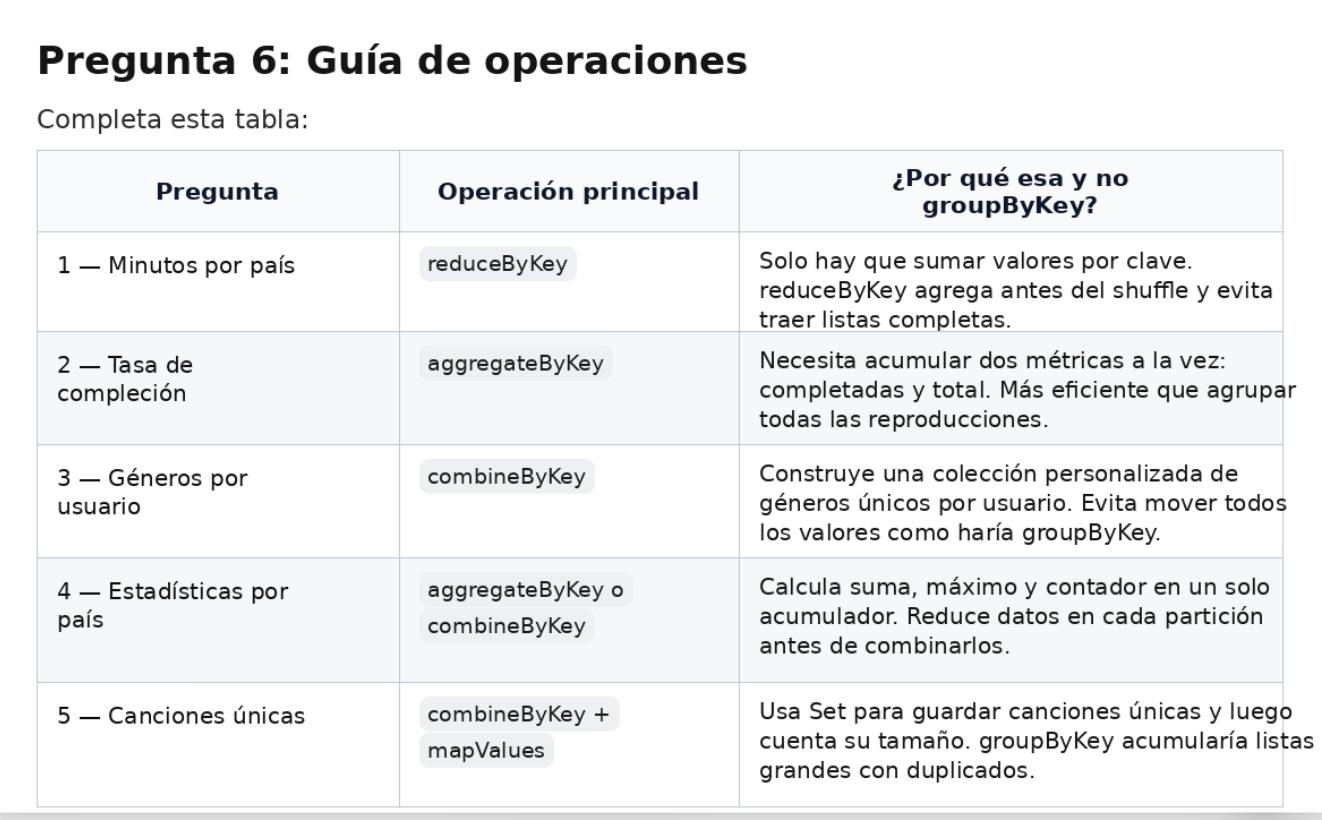